In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option('display.max_columns', None)

In [23]:
df = pd.read_csv("EDA_Task2_Sales_Dataset.csv")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 30
Columns: 7


,Date,Product,Category,Quantity,Unit_Price,Region,Total_Sales
0,2026-01-01,Laptop,Electronics,5,65000,South,325000
1,2026-01-02,Mouse,Accessories,18,1200,North,21600
2,2026-01-03,Keyboard,Accessories,12,2500,East,30000
3,2026-01-04,Monitor,Electronics,7,18000,West,126000
4,2026-01-05,Headphones,Accessories,15,3500,South,52500


In [24]:
import os
os.listdir()

['.config', 'EDA_Task2_Sales_Dataset.csv', 'sample_data']

In [25]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Dataset Shape:
(30, 7)

Column Names:
['Date', 'Product', 'Category', 'Quantity', 'Unit_Price', 'Region', 'Total_Sales']

Data Types:
Date           object
Product        object
Category       object
Quantity        int64
Unit_Price      int64
Region         object
Total_Sales     int64
dtype: object


In [26]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Date           0
Product        0
Category       0
Quantity       0
Unit_Price     0
Region         0
Total_Sales    0
dtype: int64


In [27]:
missing_percentage = (df.isnull().sum() / len(df)) * 100

print(missing_percentage)

Date           0.0
Product        0.0
Category       0.0
Quantity       0.0
Unit_Price     0.0
Region         0.0
Total_Sales    0.0
dtype: float64


In [28]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [29]:
df.describe()

,Quantity,Unit_Price,Total_Sales
count,30.000000,30.000000,30.000000
mean,12.533333,18040.000000,126556.666667
std,5.697751,24670.512903,141434.607001
min,4.000000,1200.000000,19200.000000
25%,7.250000,2500.000000,29100.000000
50%,12.500000,3500.000000,57750.000000
75%,16.750000,18000.000000,157500.000000
max,24.000000,65000.000000,520000.000000


In [30]:
df.describe(include='object')

,Date,Product,Category,Region
count,30,30,30,30
unique,30,5,2,4
top,2026-01-01,Laptop,Accessories,South
freq,1,6,18,9


In [31]:
for column in df.columns:
    print("\n", column)
    print("Unique values:", df[column].nunique())


 Date
Unique values: 30

 Product
Unique values: 5

 Category
Unique values: 2

 Quantity
Unique values: 20

 Unit_Price
Unique values: 5

 Region
Unique values: 4

 Total_Sales
Unique values: 28


In [32]:
numeric_columns = df.select_dtypes(include=np.number).columns

print("Numerical Columns:")
print(numeric_columns.tolist())

Numerical Columns:
['Quantity', 'Unit_Price', 'Total_Sales']


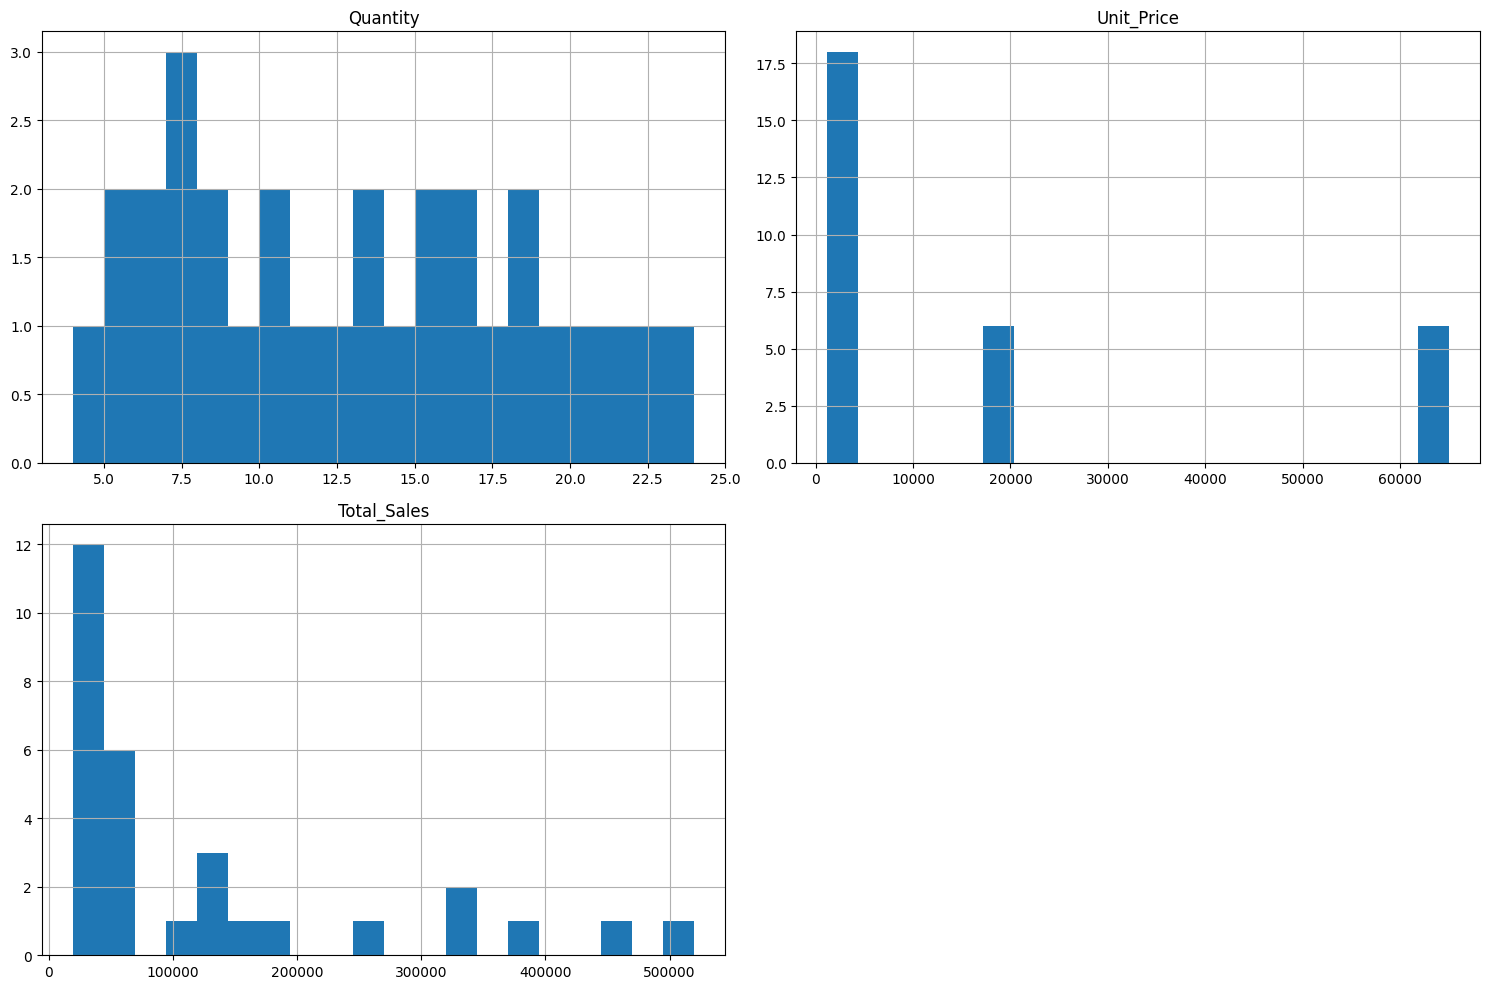

In [33]:
df[numeric_columns].hist(
    figsize=(15, 10),
    bins=20
)

plt.tight_layout()
plt.show()

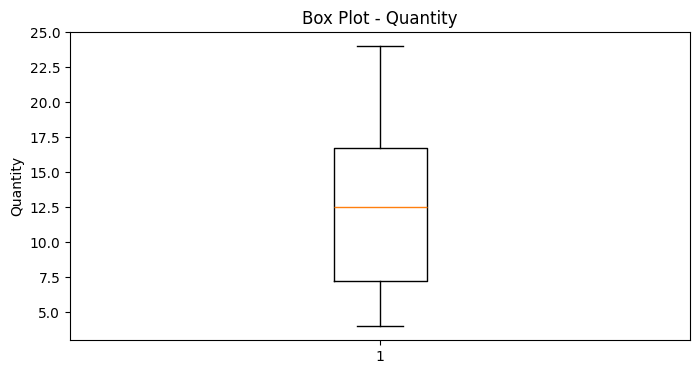

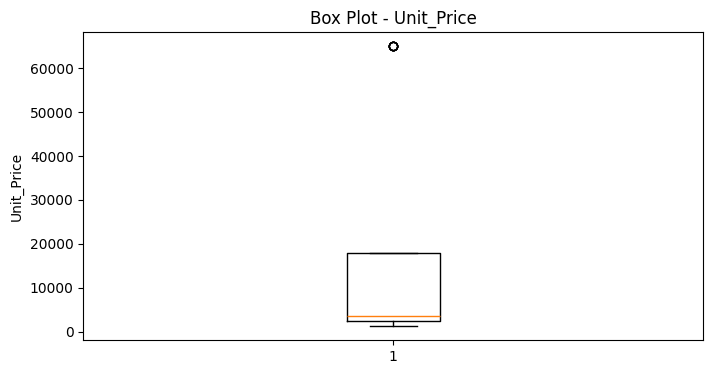

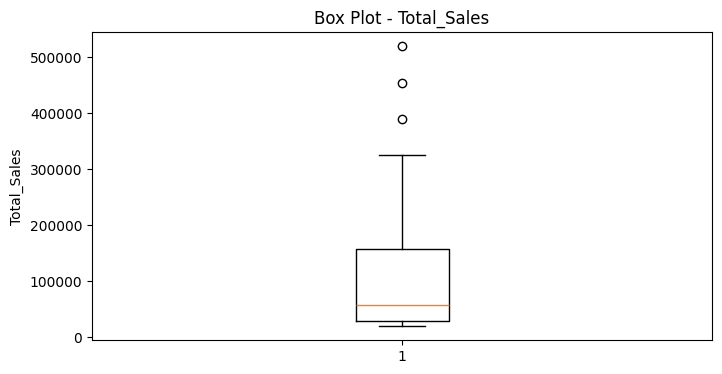

In [34]:
for column in numeric_columns:
    plt.figure(figsize=(8, 4))
    plt.boxplot(df[column].dropna())
    plt.title(f"Box Plot - {column}")
    plt.ylabel(column)
    plt.show()

In [35]:
correlation = df[numeric_columns].corr()

print(correlation)

             Quantity  Unit_Price  Total_Sales
Quantity     1.000000   -0.732588    -0.673499
Unit_Price  -0.732588    1.000000     0.953210
Total_Sales -0.673499    0.953210     1.000000


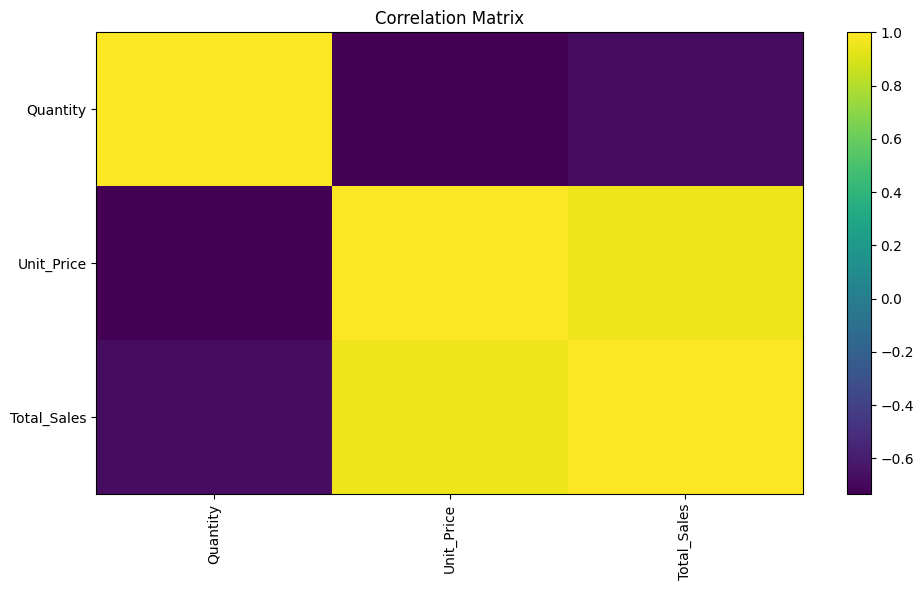

In [36]:
plt.figure(figsize=(10, 6))

plt.imshow(correlation, aspect='auto')
plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [37]:
print("===== DATA QUALITY REPORT =====")

print("\nTotal Rows:", len(df))
print("Total Columns:", len(df.columns))
print("Duplicate Rows:", df.duplicated().sum())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

===== DATA QUALITY REPORT =====

Total Rows: 30
Total Columns: 7
Duplicate Rows: 0

Missing Values:
Date           0
Product        0
Category       0
Quantity       0
Unit_Price     0
Region         0
Total_Sales    0
dtype: int64

Data Types:
Date           object
Product        object
Category       object
Quantity        int64
Unit_Price      int64
Region         object
Total_Sales     int64
dtype: object


In [38]:
df.to_csv("EDA_Analyzed_Dataset.csv", index=False)

print("File saved successfully!")

File saved successfully!


In [39]:
files.download("EDA_Analyzed_Dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>